In [81]:
import pandas as pd
import networkx as nx
import json
from collections import defaultdict
import community.community_louvain as community_louvain
from matplotlib import pyplot as plt
import numpy as np
import random
import itertools



In [27]:
def represent_degree_distribution(G,node_list,scale='linear',rep='bars', title=''):
    degree_sequence=[G.degree(node) for node in node_list]
    from collections import Counter

    degree_counts = Counter(degree_sequence)
    min_degree=min(degree_sequence)
    max_degree=max(degree_sequence)

    degrees=list(degree_counts.keys())
    degree_count=list(degree_counts.values())

    fig,ax=plt.subplots(1,1,figsize=(5,5))
    if rep=='bars':
        ax.bar(degrees,degree_count)
    if rep=='scatter':
        ax.scatter(degrees,degree_count)
    
    if scale=='log':
        ax.set_xscale('log')
        ax.set_yscale('log')
    ax.set_xlabel('Degree',fontsize=15)
    ax.set_ylabel('#nodes',fontsize=15)
    ax.tick_params(which='major',axis='both',labelsize=15) 
    ax.set_title(title)

In [26]:
def fit_CCDF(G,node_list, title=''):
    degree_sequence=[G.degree(node) for node in node_list]
    from collections import Counter

    degree_counts = Counter(degree_sequence)
    min_degree=min(degree_sequence)
    max_degree=max(degree_sequence)

    degrees = list(range(min_degree, max_degree + 1))
    degree_count = [degree_counts.get(k, 0) for k in degrees]

    degrees=[degrees[i] for i in range(len(degrees)) if degree_count[i]!=0]
    degree_count=[degree_count[i] for i in range(len(degree_count)) if degree_count[i]!=0]

    
    cdf=np.cumsum(degree_count)/G.number_of_nodes() ### Get the cumulative sum of the distribution (without normalized)
    ccdf=np.ones(len(cdf))-cdf #### Get the CCDF 

    log_degree_fit=[np.log(degrees[i]) for i in range(len(degrees))][:-1] ## Last point should be excluded as 0 in logarithmic scale is not finite
    log_ccdf_fit=np.log(ccdf)[:-1]

    m,b = np.polyfit(log_degree_fit, log_ccdf_fit, 1) 

    theoretical=[np.exp(b)*k**m for k in degrees]

    fig,ax=plt.subplots(1,1,figsize=(5,5))

    ax.plot(degrees, theoretical,color='black',label=r'$\gamma-1=%.2f$'%(-m))
    ax.scatter(degrees, ccdf,label='data')


    ax.set_yscale('log')
    ax.set_xscale('log')

    ax.set_xlabel('$k$',fontsize=15)
    ax.set_ylabel('$CCDF(k)$',fontsize=15)

    ax.tick_params(which='major',axis='both',labelsize=15)

    ax.legend()
    ax.set_title(title)

In [18]:
# =========================================================
# LOAD JSON
# =========================================================

with open(
    "./doi_10_5061_dryad_dr7sqv9v8__v20200626/"
    "NJC19_network_data_and_code/"
    "NJC19_network.json"
) as f:

    data = json.load(f)

# =========================================================
# CREATE DIRECTED BIPARTITE MULTIGRAPH
# =========================================================
#
# WHY MultiDiGraph?
#
# - Multi:
#   same species/metabolite pair can have
#   multiple interaction types
#
# - Di:
#   direction represents metabolic flow
#
# - Bipartite:
#   species and metabolites are separate node sets
#
# =========================================================

B = nx.MultiDiGraph()

# =========================================================
# ACTIVITY CLASSIFICATION
# =========================================================

activity_map = {

    "Consumption (import)": {
        "category": "import",
        "sign": 1
    },

    "Production (export)": {
        "category": "export",
        "sign": 1
    },

    "Consumption (import), Production (export)": {
        "category": "exchange",
        "sign": 1
    },

    "Macromolecule degradation": {
        "category": "degradation",
        "sign": 1
    },

    "Consumption (import) (-)": {
        "category": "import",
        "sign": -1
    },

    "Production (export) (-)": {
        "category": "export",
        "sign": -1
    },

    "Macromolecule degradation (-)": {
        "category": "degradation",
        "sign": -1
    }
}

# =========================================================
# BUILD NETWORK
# =========================================================

for interaction_id, interaction in data.items():

    # -----------------------------------------------------
    # Extract fields
    # -----------------------------------------------------

    species = interaction["Species"].strip().lower()

    metabolite = interaction[
        "Small-molecule metabolite or macromolecule"
    ].strip().lower()

    activity = interaction["Metabolic activity"]

    refs = interaction["Ref. #"]

    # -----------------------------------------------------
    # Parse activity metadata
    # -----------------------------------------------------

    parsed = activity_map[activity]

    category = parsed["category"]
    sign = parsed["sign"]

    # -----------------------------------------------------
    # Add species node
    # -----------------------------------------------------

    B.add_node(
        species,

        bipartite=0,
        node_type="species",

        label=species
    )

    # -----------------------------------------------------
    # Add metabolite node
    # -----------------------------------------------------

    B.add_node(
        metabolite,

        bipartite=1,
        node_type="metabolite",

        label=metabolite
    )

    # =====================================================
    # DEFINE EDGE DIRECTION
    # =====================================================
    #
    # IMPORT:
    # metabolite -> species
    #
    # EXPORT:
    # species -> metabolite
    #
    # EXCHANGE:
    # both directions
    #
    # DEGRADATION:
    # metabolite -> species
    #
    # =====================================================

    # -----------------------------------------------------
    # IMPORT
    # -----------------------------------------------------

    if category == "import":

        B.add_edge(
            metabolite,
            species,

            interaction_id=interaction_id,

            activity=activity,
            category=category,

            sign=sign,

            refs=refs
        )

    # -----------------------------------------------------
    # EXPORT
    # -----------------------------------------------------

    elif category == "export":

        B.add_edge(
            species,
            metabolite,

            interaction_id=interaction_id,

            activity=activity,
            category=category,

            sign=sign,

            refs=refs
        )

    # -----------------------------------------------------
    # EXCHANGE
    # -----------------------------------------------------

    elif category == "exchange":

        # species exports metabolite
        B.add_edge(
            species,
            metabolite,

            interaction_id=f"{interaction_id}_export",

            activity=activity,
            category="export",

            sign=sign,

            refs=refs
        )

        # species imports metabolite
        B.add_edge(
            metabolite,
            species,

            interaction_id=f"{interaction_id}_import",

            activity=activity,
            category="import",

            sign=sign,

            refs=refs
        )

    # -----------------------------------------------------
    # DEGRADATION
    # -----------------------------------------------------

    elif category == "degradation":

        B.add_edge(
            metabolite,
            species,

            interaction_id=interaction_id,

            activity=activity,
            category=category,

            sign=sign,

            refs=refs
        )

# =========================================================
# BASIC SUMMARY
# =========================================================

species_nodes = [
    n for n, d in B.nodes(data=True)
    if d["bipartite"] == 0
]

metabolite_nodes = [
    n for n, d in B.nodes(data=True)
    if d["bipartite"] == 1
]

print("=" * 60)
print("DIRECTED BIPARTITE METABOLIC NETWORK")
print("=" * 60)

print(f"Total nodes: {B.number_of_nodes()}")
print(f"Total edges: {B.number_of_edges()}")

print()

print(f"Species nodes: {len(species_nodes)}")
print(f"Metabolite nodes: {len(metabolite_nodes)}")

# =========================================================
# CHECK BIPARTITE STRUCTURE
# =========================================================

is_bipartite = nx.is_bipartite(B)

print()
print(f"Is bipartite: {is_bipartite}")


# =========================================================
# EDGE CATEGORY COUNTS
# =========================================================

from collections import Counter

edge_categories = Counter()

for _, _, data in B.edges(data=True):

    edge_categories[data["category"]] += 1

print()
print("Edge categories:")

for category, count in edge_categories.items():

    print(f"  {category}: {count}")

# =========================================================
# OPTIONAL:
# SHOW EXAMPLE EDGES
# =========================================================

print()
print("=" * 60)
print("EXAMPLE EDGES")
print("=" * 60)

for i, (u, v, d) in enumerate(B.edges(data=True)):

    print(
        f"{u} -> {v} | "
        f"{d['category']} | "
        f"sign={d['sign']}"
    )

    if i >= 9:
        break

DIRECTED BIPARTITE METABOLIC NETWORK
Total nodes: 1127
Total edges: 9316

Species nodes: 844
Metabolite nodes: 283

Is bipartite: True

Edge categories:
  export: 3041
  import: 5798
  degradation: 477

EXAMPLE EDGES
absiella dolichum -> acetate | export | sign=1
absiella dolichum -> butyrate | export | sign=1
absiella dolichum -> h2s (hs-) | export | sign=-1
absiella dolichum -> l-lactate ([s]-lactate, lactate, d-lactate, [r]-lactate) | export | sign=1
absiella dolichum -> nh3 (ammonia, nh4+, ammonium) | export | sign=1
absiella dolichum -> pyruvate | export | sign=1
absiella dolichum -> succinate | export | sign=1
acetate -> actinosynnema mirum | import | sign=-1
acetate -> alicycliphilus denitrificans | import | sign=1
acetate -> anaerobutyricum hallii | import | sign=1


## Analyzing the bipartite network

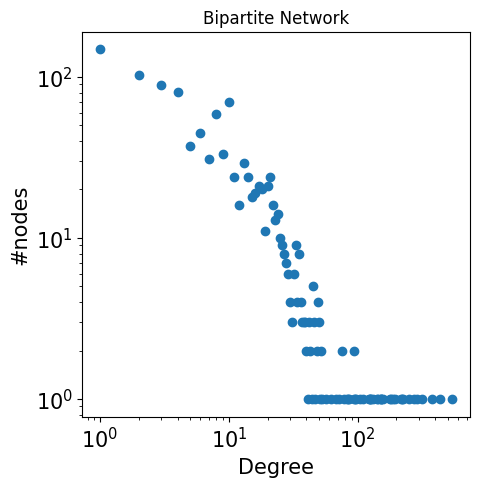

In [28]:
represent_degree_distribution(B,node_list=B.nodes(),scale='log',rep='scatter', title='Bipartite Network') ## Represent the degree distribution of the graph with a scatter plot and log scale


/var/folders/c5/kvs4zf7x2sl0k1z2fdtkxl5h0000gn/T/ipykernel_86736/1294712512.py:20: RuntimeWarning: divide by zero encountered in log
  log_ccdf_fit=np.log(ccdf)[:-1]


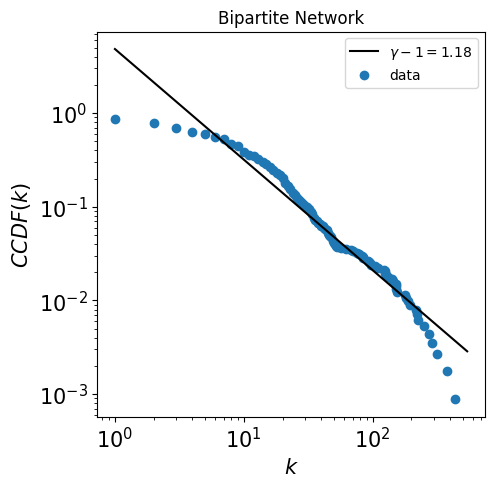

In [29]:
fit_CCDF(B,node_list=B.nodes(), title='Bipartite Network') ## Fit the CCDF of the degree distribution with a power law and represent it in a log-log scale

Species table

Here we identify

generalist bacteria (high degree)
specialists (low degree)

Metabolite table

hub metabolites (used by many species)
rare metabolites (specialized compounds)

In [ ]:
# =========================================================
# ASSUMPTION:
# B is already built and contains:
# - species nodes (bipartite=0)
# - metabolite nodes (bipartite=1)
# - directed edges species ↔ metabolites
# =========================================================

# =========================================================
# SPLIT NODES BY TYPE
# =========================================================

species_nodes = [
    n for n, d in B.nodes(data=True)
    if d.get("bipartite") == 0 or d.get("node_type") == "species"
]

metabolite_nodes = [
    n for n, d in B.nodes(data=True)
    if d.get("bipartite") == 1 or d.get("node_type") == "metabolite"
]

# =========================================================
# DEGREE CALCULATION FUNCTIONS
# =========================================================
#
# In a directed bipartite metabolic network:
# - degree = total interactions (in + out)
# - in-degree = what comes into node
# - out-degree = what leaves node
#
# =========================================================

def compute_degrees(G, nodes):

    results = []

    for n in nodes:

        indeg = G.in_degree(n)
        outdeg = G.out_degree(n)
        total = indeg + outdeg

        results.append({
            "node": n,
            "in_degree": indeg,
            "out_degree": outdeg,
            "total_degree": total
        })

    return pd.DataFrame(results)

# =========================================================
# SPECIES DEGREE ANALYSIS
# =========================================================

species_df = compute_degrees(B, species_nodes)
species_df = species_df.sort_values("total_degree", ascending=False)

print("\n" + "="*60)
print("TOP SPECIES BY DEGREE")
print("="*60)
print(species_df.head(20))

# =========================================================
# METABOLITE DEGREE ANALYSIS
# =========================================================

metabolite_df = compute_degrees(B, metabolite_nodes)
metabolite_df = metabolite_df.sort_values("total_degree", ascending=False)

print("\n" + "="*60)
print("TOP METABOLITES BY DEGREE")
print("="*60)
print(metabolite_df.head(20))

# =========================================================
# SUMMARY STATS
# =========================================================

print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)

print("\nSpecies degree stats:")
print(species_df["total_degree"].describe())

print("\nMetabolite degree stats:")
print(metabolite_df["total_degree"].describe())


TOP SPECIES BY DEGREE
                             node  in_degree  out_degree  total_degree
838              human colonocyte        120           4           124
843         mouse intestinal cell         60          18            78
106  bacteroides thetaiotaomicron         47          29            76
120        bifidobacterium longum         40          22            62
116         bifidobacterium breve         38          14            52
311              escherichia coli         21          28            49
216       clostridium perfringens         30          18            48
292         enterococcus faecalis         32          15            47
115       bifidobacterium bifidum         30          16            46
97             bacteroides ovatus         31          15            46
112  bifidobacterium adolescentis         31          15            46
446       lactobacillus plantarum         31          14            45
108          bacteroides vulgatus         34          

## Analyzing Bipartite Network individually

In [142]:
# =========================================================
# CENTRALITY MEASURES (Directly from original MultiGraph B)
# =========================================================

degree_centrality = nx.degree_centrality(B)
betweenness_centrality = nx.betweenness_centrality(B)
closeness_centrality = nx.closeness_centrality(B)

# NetworkX requires a simple graph for Eigenvector Centrality
# We cast it inline here so B itself remains completely untouched
B_simple_temp = nx.DiGraph(B) if B.is_directed() else nx.Graph(B)
eigenvector_centrality = nx.eigenvector_centrality(B_simple_temp, max_iter=1000)

# =========================================================
# ASSORTATIVITY
# =========================================================

degree_assortativity = nx.degree_assortativity_coefficient(B)

# =========================================================
# CLUSTERING (Requires undirected simple graph inline)
# =========================================================

B_undirected_temp = B.to_undirected() if B.is_directed() else B
B_undirected_simple = nx.Graph(B_undirected_temp)

clustering_coeffs = nx.clustering(B_undirected_simple)
avg_clustering = nx.average_clustering(B_undirected_simple)

# =========================================================
# COMPILE CENTRALITY RESULTS
# =========================================================

centrality_df = pd.DataFrame({
    "node": list(B.nodes()),
    "degree_centrality": [degree_centrality[n] for n in B.nodes()],
    "betweenness_centrality": [betweenness_centrality[n] for n in B.nodes()],
    "closeness_centrality": [closeness_centrality[n] for n in B.nodes()],
    "eigenvector_centrality": [eigenvector_centrality[n] for n in B.nodes()],
    "clustering_coefficient": [clustering_coeffs[n] for n in B.nodes()]
})

# =========================================================
# PRINT SUMMARY & TOP 5 HIGHEST VALUES PER METRIC
# =========================================================

print("=" * 60)
print("NETWORK CENTRALITY & ASSORTATIVITY ANALYSIS")
print("=" * 60)

print(f"\nDegree Assortativity: {degree_assortativity:.4f}")
print(f"Average Clustering Coefficient: {avg_clustering:.4f}")

print("\n" + "=" * 60)
print("TOP 5 NODES FOR EACH METRIC")
print("=" * 60)

metrics = [
    "degree_centrality", 
    "betweenness_centrality", 
    "closeness_centrality", 
    "eigenvector_centrality",
    "clustering_coefficient"
]

for metric in metrics:
    print(f"\nRANKING BY: {metric.upper()}")
    # Sort by the current metric, slice the top 5, and drop index for clean display
    top_5 = centrality_df[["node", metric]].sort_values(metric, ascending=False).head(5)
    print(top_5.to_string(index=False))
    print("-" * 40)

NETWORK CENTRALITY & ASSORTATIVITY ANALYSIS

Degree Assortativity: -0.4235
Average Clustering Coefficient: 0.0000

TOP 5 NODES FOR EACH METRIC

RANKING BY: DEGREE_CENTRALITY
                                                    node  degree_centrality
                                                 acetate           0.482238
                                                     co2           0.388099
l-lactate ([s]-lactate, lactate, d-lactate, [r]-lactate)           0.337478
                                     d-glucose (glucose)           0.279751
                                           h2 (hydrogen)           0.256661
----------------------------------------

RANKING BY: BETWEENNESS_CENTRALITY
                                                    node  betweenness_centrality
                                                     co2                0.119737
                                                 acetate                0.107608
l-lactate ([s]-lactate, lactate, d-lactate, [r]-la

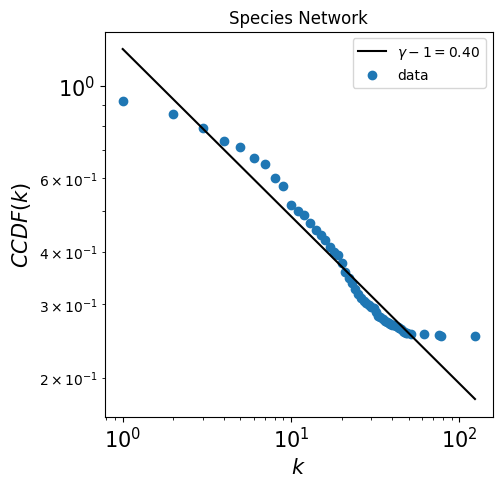

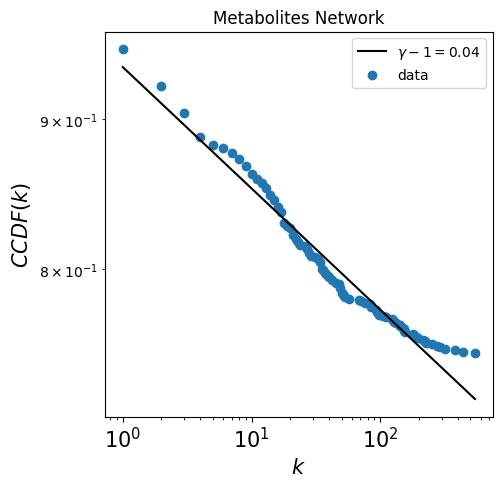

In [31]:
species_nodes = [
    n for n, d in B.nodes(data=True)
    if d.get("bipartite") == 0 or d.get("node_type") == "species"
]

metabolite_nodes = [
    n for n, d in B.nodes(data=True)
    if d.get("bipartite") == 1 or d.get("node_type") == "metabolite"
]

fit_CCDF(B, node_list=species_nodes, title='Species Network')
fit_CCDF(B, node_list=metabolite_nodes, title='Metabolites Network')

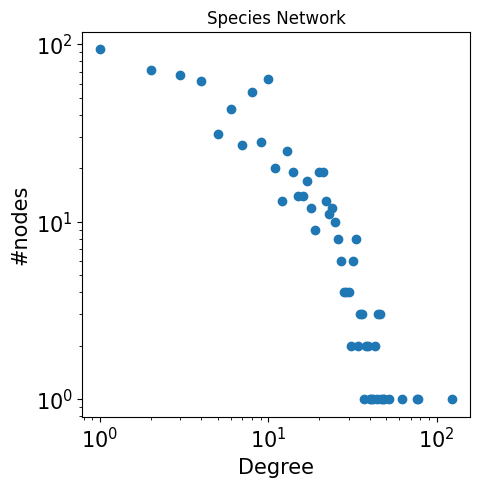

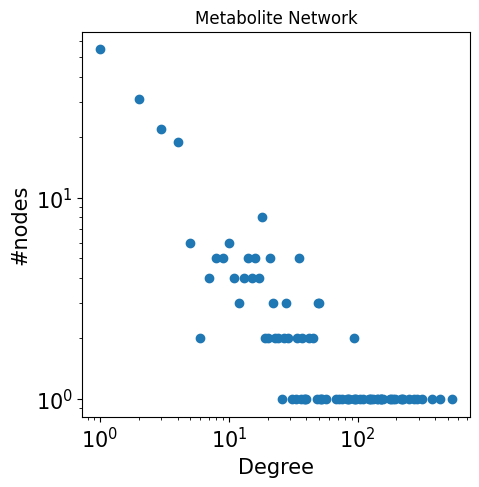

In [39]:
represent_degree_distribution(
    B,
    node_list=species_nodes,
    scale='log',
    rep='scatter',
	title='Species Network'
)

represent_degree_distribution(
    B,
    node_list=metabolite_nodes,
    scale='log',
    rep='scatter',
	title='Metabolite Network'
	
)

## Robustness of the bipartite network 

In [51]:
def largest_component_size(G):

    # convert to undirected for connectivity analysis
    H = G.to_undirected()

    components = list(nx.connected_components(H))

    if len(components) == 0:
        return 0

    return max(len(c) for c in components)


def attack_simulation(G, nodes, strategy="random", centrality=None, steps=50):

    G = G.copy()

    results = []

    # ---------------------------------------------
    # ranking strategy
    # ---------------------------------------------

    if strategy == "random":
        ranked = nodes.copy()

    elif strategy == "degree":
        ranked = sorted(nodes, key=lambda n: G.degree(n), reverse=True)

    elif strategy == "centrality":
        ranked = sorted(nodes, key=lambda n: centrality.get(n, 0), reverse=True)

    else:
        raise ValueError("Unknown strategy")

    # ---------------------------------------------
    # removal loop
    # ---------------------------------------------

    for i in range(steps):

        if len(ranked) == 0:
            break

        if strategy == "random":
            node = random.choice(ranked)
            ranked.remove(node)
        else:
            node = ranked.pop(0)

        if node in G:
            G.remove_node(node)

        results.append({
            "step": i,
            "LCC": largest_component_size(G)
        })

    return pd.DataFrame(results)

In [43]:
betweenness = nx.betweenness_centrality(B)

In [53]:
all_nodes = list(B.nodes())

In [54]:
random_results = attack_simulation(
    B,
    all_nodes,
    strategy="random",
    steps=50
)

In [59]:
targeted_results = attack_simulation(
    B,
    all_nodes,
    strategy="degree",
    steps=50
)

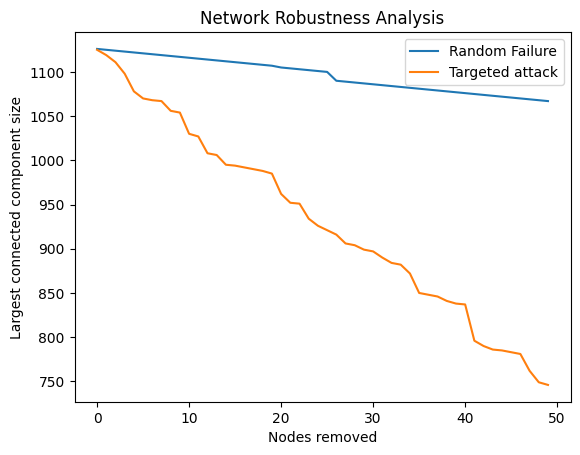

In [60]:
plt.figure()

plt.plot(random_results["step"], random_results["LCC"],
         label="Random Failure")

plt.plot(targeted_results["step"], targeted_results["LCC"],
         label="Targeted attack")

plt.xlabel("Nodes removed")
plt.ylabel("Largest connected component size")
plt.title("Network Robustness Analysis")

plt.legend()
plt.show()

## Robustness of the bipartite network individually

In [44]:
species_attack_random = attack_simulation(
    B,
    species_nodes,
    strategy="random"
)

species_attack_degree = attack_simulation(
    B,
    species_nodes,
    strategy="degree"
)

species_attack_betweenness = attack_simulation(
    B,
    species_nodes,
    strategy="centrality",
    centrality=betweenness
)

In [45]:
metabolite_attack_random = attack_simulation(
    B,
    metabolite_nodes,
    strategy="random"
)

metabolite_attack_degree = attack_simulation(
    B,
    metabolite_nodes,
    strategy="degree"
)

metabolite_attack_betweenness = attack_simulation(
    B,
    metabolite_nodes,
    strategy="centrality",
    centrality=betweenness
)

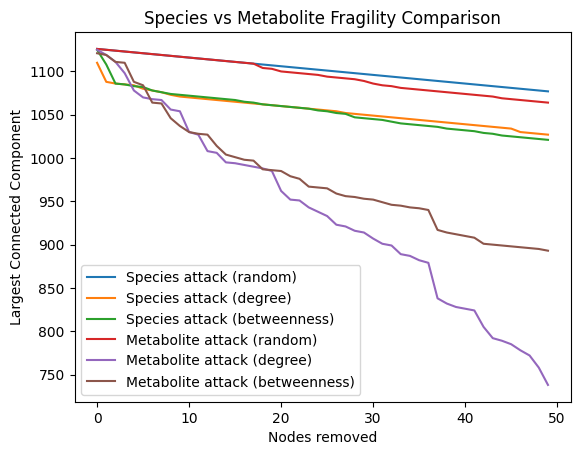

In [50]:
plt.figure()

# Species
plt.plot(species_attack_random["step"], species_attack_random["LCC"],
         label="Species attack (random)")

plt.plot(species_attack_degree["step"], species_attack_degree["LCC"],
         label="Species attack (degree)")

plt.plot(species_attack_betweenness["step"], species_attack_betweenness["LCC"],
         label="Species attack (betweenness)")

# Metabolites
plt.plot(metabolite_attack_random["step"], metabolite_attack_random["LCC"],
         label="Metabolite attack (random)")


plt.plot(metabolite_attack_degree["step"], metabolite_attack_degree["LCC"],
         label="Metabolite attack (degree)")

plt.plot(metabolite_attack_betweenness["step"], metabolite_attack_betweenness["LCC"],
         label="Metabolite attack (betweenness)")

plt.xlabel("Nodes removed")
plt.ylabel("Largest Connected Component")
plt.title("Species vs Metabolite Fragility Comparison")
plt.legend()
plt.show()

## Nestedness

In [66]:
# ---------------------------------------------------------
# UNIQUE NODE LISTS
# ---------------------------------------------------------

species_nodes = sorted(species_nodes)
metabolite_nodes = sorted(metabolite_nodes)

# ---------------------------------------------------------
# INDEX MAPS
# ---------------------------------------------------------

species_index = {
    s: i for i, s in enumerate(species_nodes)
}

metabolite_index = {
    m: j for j, m in enumerate(metabolite_nodes)
}

# ---------------------------------------------------------
# EMPTY MATRIX
# ---------------------------------------------------------

M = np.zeros(
    (len(species_nodes), len(metabolite_nodes)),
    dtype=int
)

# ---------------------------------------------------------
# FILL MATRIX
# ---------------------------------------------------------

for u, v in B.edges():

    u_type = B.nodes[u]["node_type"]
    v_type = B.nodes[v]["node_type"]

    # species -> metabolite
    if u_type == "species":

        s = u
        m = v

    # metabolite -> species
    else:

        s = v
        m = u

    i = species_index[s]
    j = metabolite_index[m]

    M[i, j] = 1

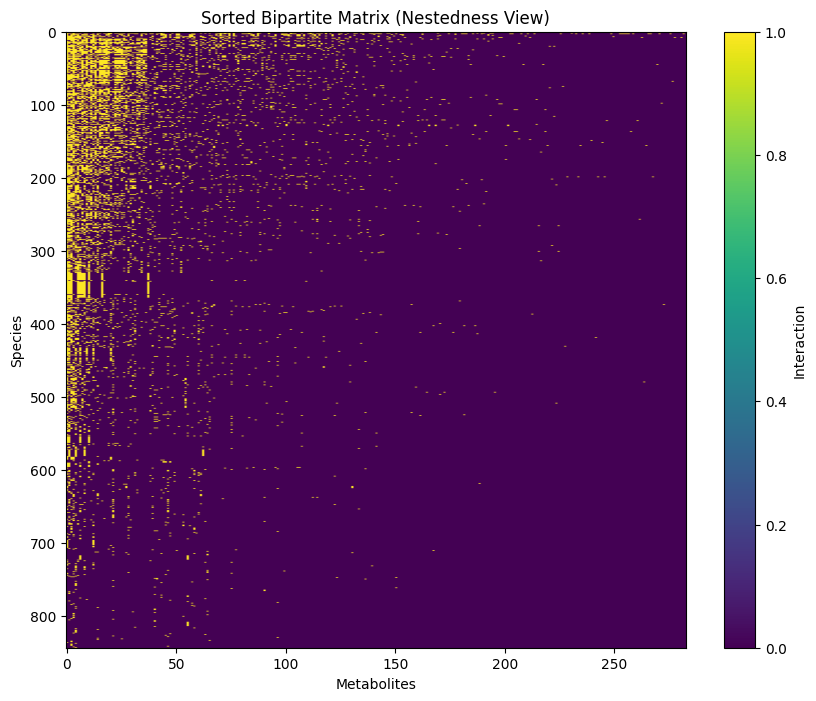

In [69]:
# ---------------------------------------------------------
# sort rows and columns by degree
# ---------------------------------------------------------

row_order = np.argsort(M.sum(axis=1))[::-1]
col_order = np.argsort(M.sum(axis=0))[::-1]

M_sorted = M[row_order][:, col_order]

# ---------------------------------------------------------
# visualize sorted matrix
# ---------------------------------------------------------

plt.figure(figsize=(10, 8))

plt.imshow(M_sorted, aspect="auto")

plt.title("Sorted Bipartite Matrix (Nestedness View)")
plt.xlabel("Metabolites")
plt.ylabel("Species")

plt.colorbar(label="Interaction")

plt.show()

In [ ]:
# This library doesn't exist but I copy and paste it from the original code 
# in the following repository https://github.com/tsakim/nestedness

class NestednessCalculator(object):
    """Calculates the nestedness of the input matrix.

    The algorithms that have been implemented are:
        - NODF (Nestedness based on Overlap and Decreasing Fill)
    """
    def __init__(self, mat):
        """Initialize the Nestedness calculator and check the input matrix.

        :param mat: binary input matrix
        :type mat: numpy.array
        """
        self.check_input_matrix_is_binary(mat)
        self.check_degrees(mat)

    @staticmethod
    def check_input_matrix_is_binary(mat):
        """Check that the input matrix is binary, i.e. entries are 0 or 1.

        :param mat: binary input matrix
        :type mat: numpy.array

        :raise AssertionError: raise an error if the input matrix is not
            binary
        """
        assert np.all(np.logical_or(mat == 0, mat == 1)), \
            "Input matrix is not binary."

    @staticmethod
    def check_degrees(mat):
        """Check that rows and columns are not completely zero.

        :param mat: binary input matrix
        :type mat: numpy.array

        :raise AssertionError: raise an error if the input matrix has
            completely zero rows or columns.
        """
        assert np.all(mat.sum(axis=1) != 0), \
            "Input matrix rows with only zeros, abort."
        assert np.all(mat.sum(axis=0) != 0), \
            "Input matrix columns with only zeros, abort."

################################################################################
# NODF - Nestedness based on Overlap and Decreasing Fill
################################################################################

    def get_paired_nestedness(self, mat, rows=True):
        """Calculate the paired nestedness along the rows or columns of the.

        :param mat: binary input matrix
        :type mat: numpy.array
        :param rows: if True, pairs are calculated along the rows, if False
            along the columns
        :type rows: bool

        :returns: degree of paired nestedness
        :rtype: float

        The method uses the algorithm described in the `BiMat framework for
        MATLAB <https://bimat.github.io/alg/nestedness.html>`_.
        """
        if rows:
            # consider rows
            po_mat = np.dot(mat, mat.T)
            degrees = mat.sum(axis=1)
        else:
            # consider cols
            po_mat = np.dot(mat.T, mat)
            degrees = mat.sum(axis=0)
        assert len(degrees) == len(po_mat)

        neg_delta = (degrees != degrees[:, np.newaxis])
        deg_matrix = degrees * np.ones_like(po_mat)
        deg_minima = np.minimum(deg_matrix, deg_matrix.T)
        n_pairs = po_mat[neg_delta] / (2. * deg_minima[neg_delta])
        return n_pairs.sum()

    def nodf(self, mat):
        """Calculate the NODF nestedness of the input matrix [AlmeidaNeto]_.

        :param mat: binary input matrix
        :type mat: numpy.array

        :returns: NODF nestedness of the input matrix
        :rtype: float


        The algorithm has been tested by comparison with the `online tool
        provided at <http://ecosoft.alwaysdata.net/>`_
        """
        n_pairs_rows = self.get_paired_nestedness(mat, rows=True)
        n_pairs_cols = self.get_paired_nestedness(mat, rows=False)
        norm = np.sum(np.array(mat.shape) * (np.array(mat.shape) - 1) / 2.)
        nodf = (n_pairs_rows + n_pairs_cols) / norm
        return nodf

In [72]:

calculator = NestednessCalculator(M_sorted)

nodf = calculator.nodf(M_sorted)

print("NODF =", nodf)

NODF = 0.2977012779627041


In [77]:
# =========================================================
# NUMBER OF EDGES (L)
# =========================================================

L = B.number_of_edges()

# =========================================================
# NUMBER OF SPECIES (S)
# =========================================================

S = len([
    n for n, d in B.nodes(data=True)
    if d.get("node_type") == "species" or d.get("bipartite") == 0
])

# =========================================================
# NUMBER OF METABOLITES (M)
# =========================================================

M = len([
    n for n, d in B.nodes(data=True)
    if d.get("node_type") == "metabolite" or d.get("bipartite") == 1
])

# =========================================================
# CONNECTANCE
# =========================================================

connectance = L / (S * M)

print("=" * 60)
print("BIPARTITE CONNECTANCE")
print("=" * 60)

print(f"Species (S): {S}")
print(f"Metabolites (M): {M}")
print(f"Links (L): {L}")
print(f"Connectance (C): {connectance:.6f}")

# need to check this better

BIPARTITE CONNECTANCE
Species (S): 844
Metabolites (M): 283
Links (L): 9316
Connectance (C): 0.039003


# Competition Network

In [ ]:
species_nodes = [
    n for n, d in B.nodes(data=True)
    if d.get("node_type") == "species" or d.get("bipartite") == 0
]

metabolite_nodes = [
    n for n, d in B.nodes(data=True)
    if d.get("node_type") == "metabolite" or d.get("bipartite") == 1
]

species_to_metabolites = defaultdict(set)

for u, v, d in B.edges(data=True):

    u_type = B.nodes[u].get("node_type")

    if u_type == "species":
        species = u
        metabolite = v
    else:
        species = v
        metabolite = u

        [species].add(metabolite)

In [82]:
competition = nx.Graph()

for s in species_nodes:
    competition.add_node(s)

for s1, s2 in itertools.combinations(species_nodes, 2):

    m1 = species_to_metabolites[s1]
    m2 = species_to_metabolites[s2]

    if len(m1) == 0 or len(m2) == 0:
        continue

    intersection = len(m1 & m2)
    union = len(m1 | m2)

    if union == 0:
        continue

    weight = intersection / union  # Jaccard similarity

    if weight > 0:

        competition.add_edge(s1, s2, weight=weight)

In [83]:
print("="*60)
print("COMPETITION NETWORK")
print("="*60)

print("Species nodes:", competition.number_of_nodes())
print("Competition edges:", competition.number_of_edges())

COMPETITION NETWORK
Species nodes: 844
Competition edges: 227676


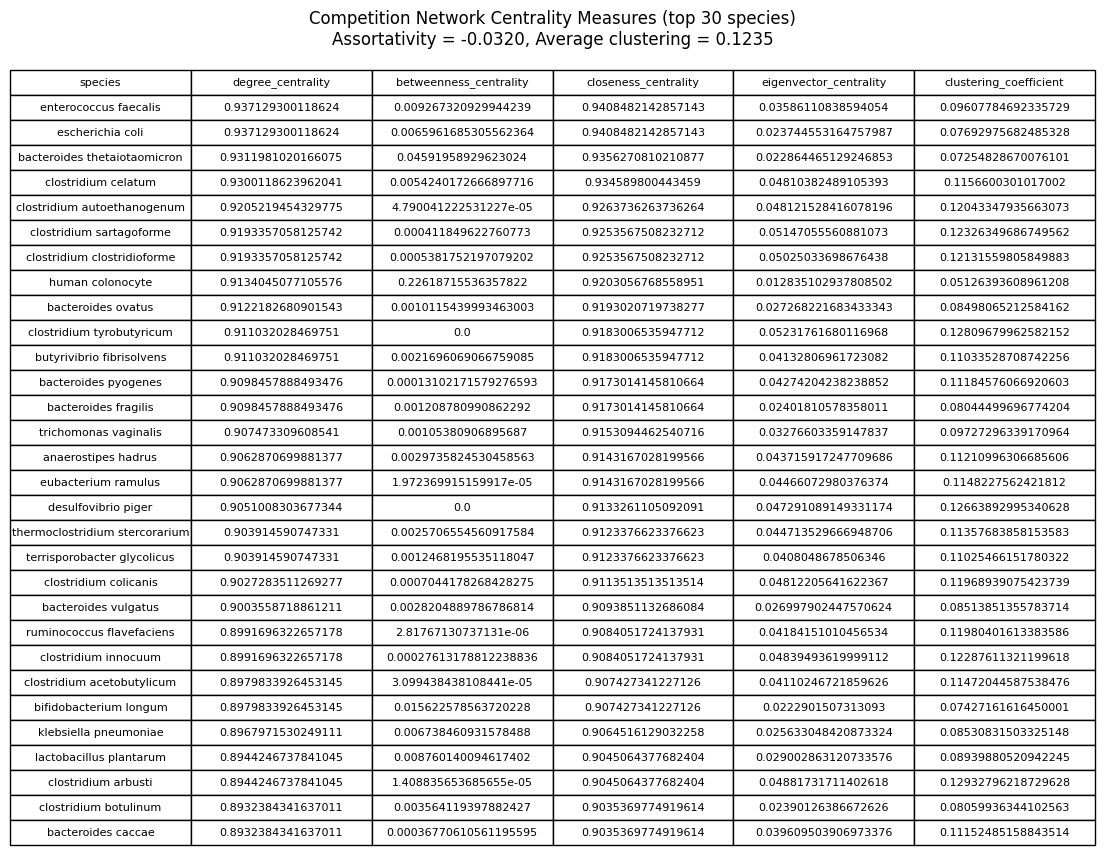

In [147]:
# compute competition network centrality measures
degree_cent = nx.degree_centrality(competition)
bet_cent = nx.betweenness_centrality(competition, weight="weight")
close_cent = nx.closeness_centrality(competition)
eig_cent = nx.eigenvector_centrality(competition, weight="weight", max_iter=1000)
clust = nx.clustering(competition, weight="weight")

assortativity = nx.degree_assortativity_coefficient(competition, weight="weight")
avg_clustering = nx.average_clustering(competition, weight="weight")

competition_df = pd.DataFrame({
	"species": list(competition.nodes()),
	"degree_centrality": [degree_cent[n] for n in competition.nodes()],
	"betweenness_centrality": [bet_cent[n] for n in competition.nodes()],
	"closeness_centrality": [close_cent[n] for n in competition.nodes()],
	"eigenvector_centrality": [eig_cent[n] for n in competition.nodes()],
	"clustering_coefficient": [clust[n] for n in competition.nodes()]
})

competition_df = competition_df.sort_values(
	by="degree_centrality",
	ascending=False
).reset_index(drop=True)

# show the top nodes in a matplotlib table
top_n = 30
top_df = competition_df.head(top_n)

fig, ax = plt.subplots(figsize=(14, 10))
ax.axis("off")

table = ax.table(
	cellText=top_df.values,
	colLabels=top_df.columns,
	cellLoc="center",
	loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.5)

ax.set_title(
	f"Competition Network Centrality Measures (top {top_n} species)\n"
	f"Assortativity = {assortativity:.4f}, "
	f"Average clustering = {avg_clustering:.4f}",
	pad=20
)

plt.show()

# Questions
Which bacteria compete most strongly?
Are there competitive clusters?

Edge weight
Could be:

* number of shared metabolites

Question:

“How much direct competition exists?”

Good for:

competition intensity
resource pressure

* Jaccard similarity

Question:

“Which species occupy similar niches?”

Best for:

modularity
community detection
ecological guilds

This is usually the BEST default.

* overlap coefficient

Question:

“Are specialists nested inside generalists?”

Best for:

hierarchical ecology
nestedness-related analyses
specialist/generalist dynamics

In [85]:
species_nodes = [
    n for n, d in B.nodes(data=True)
    if d.get("node_type") == "species" or d.get("bipartite") == 0   
]

species_to_metabolites = defaultdict(set)

for u, v in B.edges():

    u_type = B.nodes[u].get("node_type")

    if u_type == "species":
        species_to_metabolites[u].add(v)
    else:
        species_to_metabolites[v].add(u)

In [86]:
G_shared = nx.Graph()

for s in species_nodes:
    G_shared.add_node(s)

for s1, s2 in itertools.combinations(species_nodes, 2):

    w = len(species_to_metabolites[s1] & species_to_metabolites[s2])

    if w > 0:
        G_shared.add_edge(s1, s2, weight=w)

In [87]:
G_jaccard = nx.Graph()

for s in species_nodes:
    G_jaccard.add_node(s)

for s1, s2 in itertools.combinations(species_nodes, 2):

    A = species_to_metabolites[s1]
    Bm = species_to_metabolites[s2]

    if len(A | Bm) == 0:
        continue

    w = len(A & Bm) / len(A | Bm)

    if w > 0:
        G_jaccard.add_edge(s1, s2, weight=w)

In [88]:
G_overlap = nx.Graph()

for s in species_nodes:
    G_overlap.add_node(s)

for s1, s2 in itertools.combinations(species_nodes, 2):

    A = species_to_metabolites[s1]
    Bm = species_to_metabolites[s2]

    denom = min(len(A), len(Bm))

    if denom == 0:
        continue

    w = len(A & Bm) / denom

    if w > 0:
        G_overlap.add_edge(s1, s2, weight=w)

In [90]:
edges_df = []

for u, v, d in G_jaccard.edges(data=True):

    edges_df.append({
        "species_1": u,
        "species_2": v,
        "weight": d["weight"]
    })

edges_df = pd.DataFrame(edges_df)

edges_df = edges_df.sort_values("weight", ascending=False)

print("="*60)
print("STRONGEST COMPETING PAIRS")
print("="*60)
print(edges_df.head(20))

STRONGEST COMPETING PAIRS
                           species_1                       species_2  weight
223485     streptococcus infantarius             streptococcus mitis     1.0
87541      capnocytophaga gingivalis              prevotella marshii     1.0
161546      helicobacter acinonychis      methanolacinia petrolearia     1.0
223417        streptococcus ictaluri            streptococcus uberis     1.0
97615    clostridium carboxidivorans      clostridium methylpentosum     1.0
142331  enterococcus saccharolyticus          enterococcus sulfureus     1.0
223416        streptococcus ictaluri      streptococcus thoraltensis     1.0
221550      streptococcus agalactiae             streptococcus ferus     1.0
225200        streptococcus porcinus  streptococcus pseudopneumoniae     1.0
97614    clostridium carboxidivorans         clostridium ljungdahlii     1.0
225201        streptococcus porcinus    streptococcus pseudoporcinus     1.0
221548      streptococcus agalactiae              

In [148]:
edges_df = []

for u, v, d in G_shared.edges(data=True):

    edges_df.append({
        "species_1": u,
        "species_2": v,
        "weight": d["weight"]
    })

edges_df = pd.DataFrame(edges_df)

edges_df = edges_df.sort_values("weight", ascending=False)

print("="*60)
print("STRONGEST COMPETING PAIRS")
print("="*60)
print(edges_df.head(20))

STRONGEST COMPETING PAIRS
                            species_1                               species_2  \
227672               human colonocyte                   mouse intestinal cell   
50933              bacteroides ovatus            bacteroides thetaiotaomicron   
59200    bifidobacterium adolescentis                  bifidobacterium longum   
61665           bifidobacterium breve                  bifidobacterium longum   
61035         bifidobacterium bifidum                  bifidobacterium longum   
59195    bifidobacterium adolescentis                 bifidobacterium bifidum   
61031         bifidobacterium bifidum                   bifidobacterium breve   
98118             clostridium celatum             clostridium clostridioforme   
57029    bacteroides thetaiotaomicron                        human colonocyte   
59196    bifidobacterium adolescentis                   bifidobacterium breve   
56352    bacteroides thetaiotaomicron                    bacteroides vulgatus   
60

In [92]:
threshold = 0.3  # adjustable

G_filtered = nx.Graph()

for u, v, d in G_jaccard.edges(data=True):

    if d["weight"] >= threshold:

        G_filtered.add_edge(u, v, weight=d["weight"])

components = list(nx.connected_components(G_filtered))

print("="*60)
print("COMPETITIVE CLUSTERS (PRE-MODULARITY)")
print("="*60)

for i, c in enumerate(components):

    print(f"\nCluster {i+1} (size={len(c)}):")
    print(list(c)[:10])

COMPETITIVE CLUSTERS (PRE-MODULARITY)

Cluster 1 (size=808):
['lactobacillus pasteurii', 'clostridium celatum', 'bacteroides gallinarum', 'ignavibacterium album', 'paraclostridium bifermentans', 'streptococcus henryi', 'gemella bergeri', 'bacteroides dorei', 'schaalia odontolytica', 'bacteroides thetaiotaomicron']

Cluster 2 (size=2):
['acidovorax avenae', 'acidovorax delafieldii']

Cluster 3 (size=5):
['brucella abortus', 'corynebacterium diphtheriae', 'neisseria gonorrhoeae', 'brucella melitensis', 'brucella suis']

Cluster 4 (size=2):
['gluconobacter oxydans', 'ketogulonicigenium vulgare']

Cluster 5 (size=3):
['mitsuokella multacida', 'human goblet cell', 'mouse goblet cell']

Cluster 6 (size=2):
['human colonocyte', 'mouse intestinal cell']


In [93]:
G = G_jaccard

partition = community_louvain.best_partition(
    G,
    weight="weight"
)

In [94]:
modularity_score = community_louvain.modularity(
    partition,
    G,
    weight="weight"
)

print("="*60)
print("MODULARITY ANALYSIS")
print("="*60)

print(f"Modularity score: {modularity_score:.4f}")

MODULARITY ANALYSIS
Modularity score: 0.1883


In [95]:
community_df = pd.DataFrame({
    "species": list(partition.keys()),
    "module": list(partition.values())
})

community_df = community_df.sort_values("module")

print(community_df.head(30))

                               species  module
0                    absiella dolichum       0
408          lactobacillus acidophilus       0
406  lachnoclostridium phytofermentans       0
405              lachnobacterium bovis       0
404      lachnoanaerobaculum saburreum       0
402              klebsiella pneumoniae       0
399                 johnsonella ignava       0
398         intestinibacter bartlettii       0
395              ignavibacterium album       0
393               hungatella hathewayi       0
389              holdemania filiformis       0
388              holdemanella biformis       0
369                 helcococcus kunzii       0
367           halobacteroides halobius       0
364      halanaerobium saccharolyticum       0
363           halanaerobium praevalens       0
351                  gemella sanguinis       0
350                gemella morbillorum       0
349                    gemella bergeri       0
343          fusobacterium necrophorum       0
409         l

In [96]:
module_sizes = community_df["module"].value_counts()

print("="*60)
print("MODULE SIZES")
print("="*60)

print(module_sizes)

MODULE SIZES
module
0    249
4    228
3    178
5    102
2     84
1      3
Name: count, dtype: int64


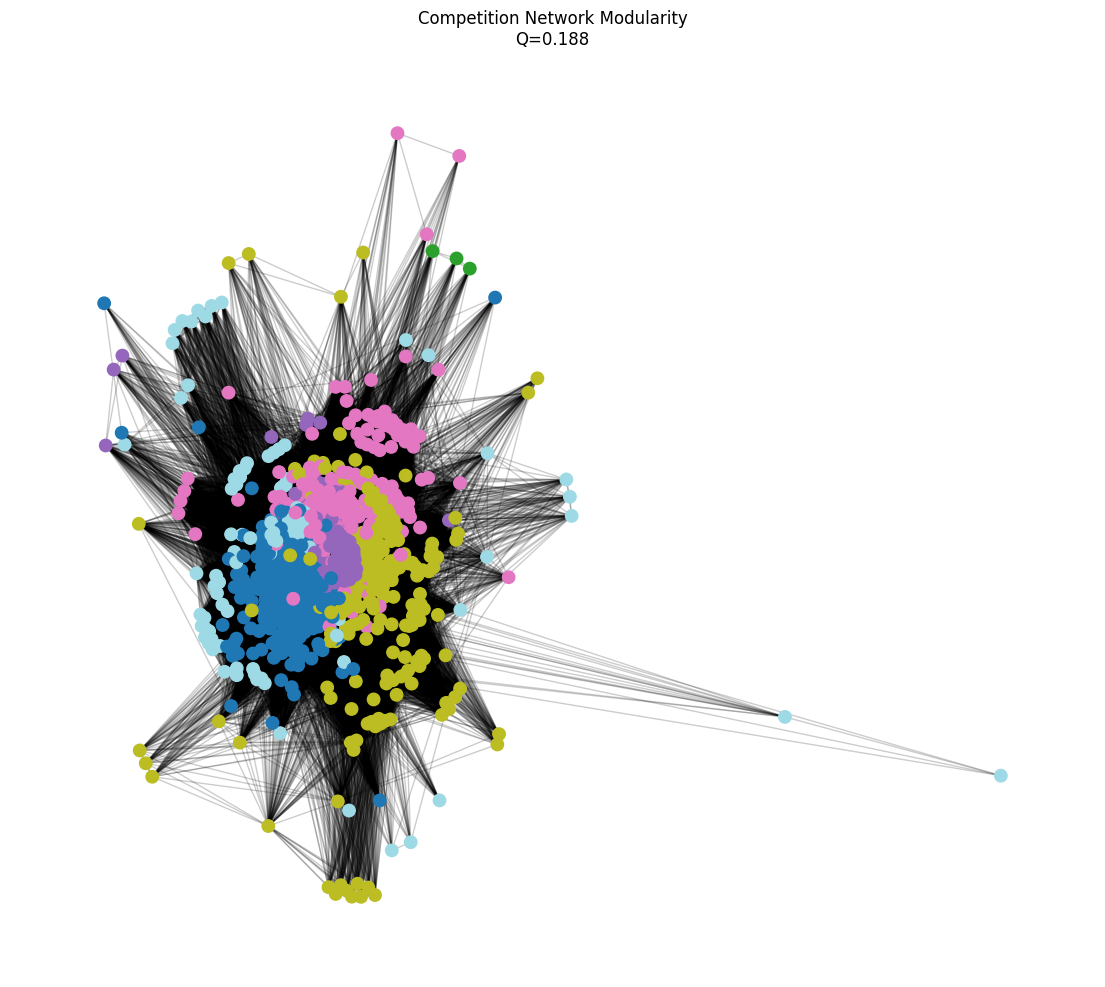

In [97]:
plt.figure(figsize=(14, 12))

pos = nx.spring_layout(
    G,
    seed=42,
    weight="weight"
)

# color nodes by module
node_colors = [
    partition[n]
    for n in G.nodes()
]

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=80,
    node_color=node_colors,
    cmap=plt.cm.tab20
)

nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.2
)

plt.title(
    f"Competition Network Modularity\nQ={modularity_score:.3f}"
)

plt.axis("off")
plt.show()

In [98]:
G = competition
partition = community_louvain.best_partition(
    G,
    weight="weight"
)

modularity_score = community_louvain.modularity(
    partition,
    G,
    weight="weight"
)

print("="*60)
print("MODULARITY ANALYSIS")
print("="*60)

print(f"Modularity score: {modularity_score:.4f}")

MODULARITY ANALYSIS
Modularity score: 0.1923


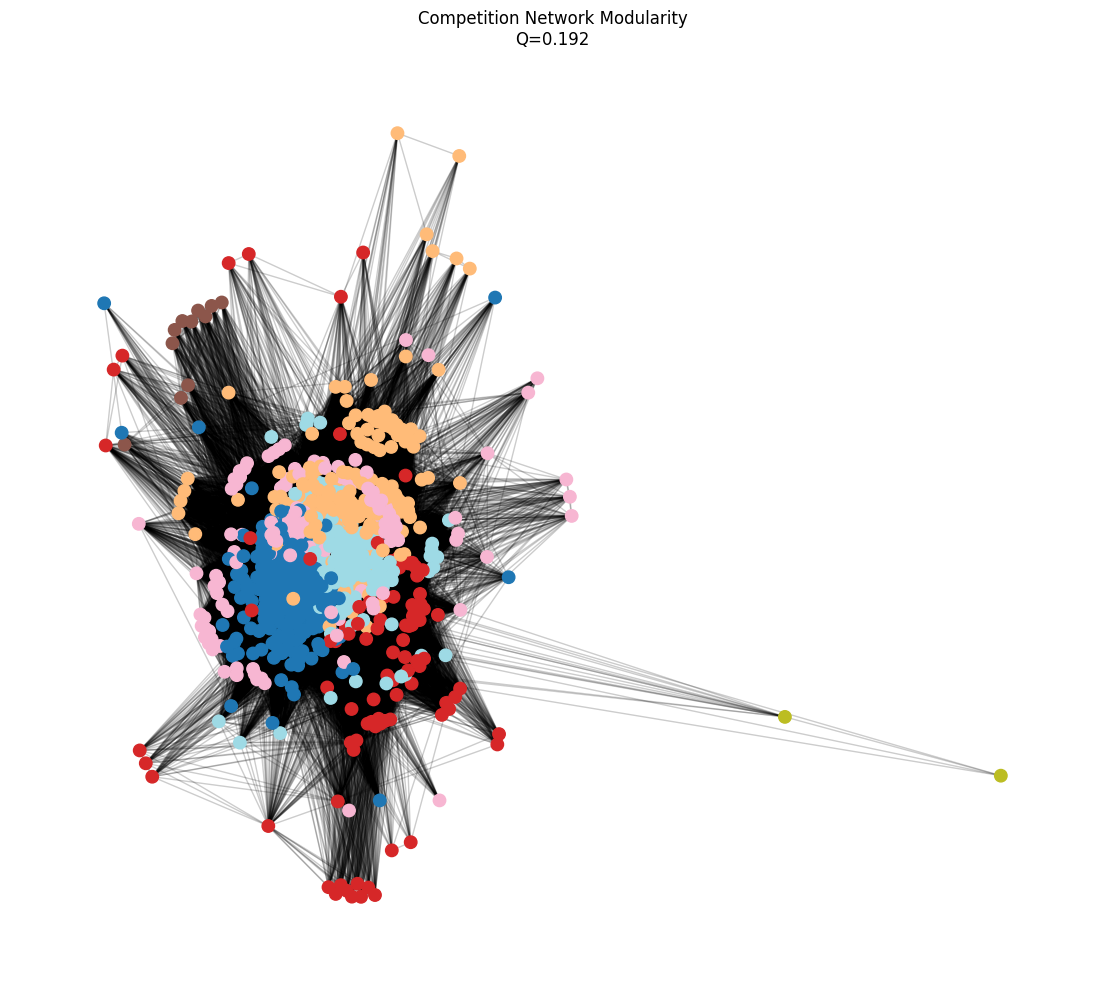

In [101]:
plt.figure(figsize=(14, 12))

pos = nx.spring_layout(
    G,
    seed=42,
    weight="weight"
)

# color nodes by module
node_colors = [
    partition[n]
    for n in G.nodes()
]

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=80,
    node_color=node_colors,
    cmap=plt.cm.tab20
)

nx.draw_networkx_edges(
    G,
    pos,
    alpha=0.2
)

plt.title(
    f"Competition Network Modularity\nQ={modularity_score:.3f}"
)

plt.axis("off")
plt.show()

In [102]:
module_to_species = defaultdict(list)

for species, module in partition.items():

    module_to_species[module].append(species)

In [103]:
species_to_metabolites

defaultdict(set,
            {'absiella dolichum': {'acetate',
              'butyrate',
              'cellobiose',
              'd-fructose (fructose)',
              'd-galactose',
              'd-gluconate (d-gluconic acid, gluconate)',
              'd-glucose (glucose)',
              'd-mannose (mannose)',
              'd-ribose (ribose)',
              'erythritol',
              'fructan (inulin, levan)',
              'glycerol',
              'h2s (hs-)',
              'hippurate',
              'l-lactate ([s]-lactate, lactate, d-lactate, [r]-lactate)',
              'l-sorbose (sorbose)',
              'maltose',
              'nh3 (ammonia, nh4+, ammonium)',
              'nitrate (no3-)',
              'pyruvate',
              'starch (amylopectin, amylose, 1,4-alpha-d-glucan, pullulan, resistant starch, glycogen)',
              'succinate',
              'sucrose'},
             'actinosynnema mirum': {'acetate',
              'benzoate',
              'cellobiose'

In [104]:
module_metabolites = {}

for module, species_list in module_to_species.items():

    metabolites = []

    for species in species_list:

        metabolites.extend(
            species_to_metabolites[species]
        )

    module_metabolites[module] = metabolites

In [105]:
top_k = 10

for module, metabolites in module_metabolites.items():

    counts = Counter(metabolites)

    print("\n" + "="*60)
    print(f"MODULE {module}")
    print("="*60)

    print(f"Number of species: {len(module_to_species[module])}")

    print("\nTop metabolites:")

    for metabolite, count in counts.most_common(top_k):

        print(f"{metabolite:<40} {count}")


MODULE 0
Number of species: 249

Top metabolites:
d-glucose (glucose)                      203
maltose                                  176
acetate                                  175
d-fructose (fructose)                    172
sucrose                                  162
l-lactate ([s]-lactate, lactate, d-lactate, [r]-lactate) 158
lactose                                  157
cellobiose                               143
d-mannose (mannose)                      140
raffinose                                137

MODULE 1
Number of species: 203

Top metabolites:
h2 (hydrogen)                            144
acetate                                  123
co2                                      105
formate                                  88
propanoate (propionate)                  72
l-lactate ([s]-lactate, lactate, d-lactate, [r]-lactate) 70
butyrate                                 66
succinate                                53
ethanol                                  51
h2s (hs-)        

In [106]:
# ---------------------------------------------------------
# GLOBAL FREQUENCIES
# ---------------------------------------------------------

global_counts = Counter()

for species in species_nodes:

    global_counts.update(
        species_to_metabolites[species]
    )

In [107]:
for module, metabolites in module_metabolites.items():

    local_counts = Counter(metabolites)

    enrichment_rows = []

    for metabolite, local_count in local_counts.items():

        global_count = global_counts[metabolite]

        enrichment = local_count / global_count

        enrichment_rows.append({
            "metabolite": metabolite,
            "local_count": local_count,
            "global_count": global_count,
            "enrichment": enrichment
        })

    enrichment_df = pd.DataFrame(enrichment_rows)

    enrichment_df = enrichment_df.sort_values(
        "enrichment",
        ascending=False
    )

    print("\n" + "="*60)
    print(f"MODULE {module} ENRICHED METABOLITES")
    print("="*60)

    print(
        enrichment_df.head(10)
    )


MODULE 0 ENRICHED METABOLITES
                                          metabolite  local_count  \
132                                         tyramine            7   
200                            orotic acid (orotate)            2   
190  trimethylamine n-oxide (trimethylamine-n-oxide)            1   
192                                   cl- (chloride)            3   
193                                     na+ (sodium)            3   
196                                       tryptamine            2   
197                          indole-3-carboxaldehyde            2   
198                                          thymine            2   
199                             indole-3-lactic acid            1   
201                                         xanthine            3   

     global_count  enrichment  
132             7         1.0  
200             2         1.0  
190             1         1.0  
192             3         1.0  
193             3         1.0  
196             2

In [108]:
top_metabolites = [
    m for m, _ in global_counts.most_common(20)
]

modules = sorted(module_to_species.keys())

heatmap = np.zeros(
    (len(modules), len(top_metabolites))
)

for i, module in enumerate(modules):

    counts = Counter(
        module_metabolites[module]
    )

    for j, metabolite in enumerate(top_metabolites):

        heatmap[i, j] = counts.get(metabolite, 0)

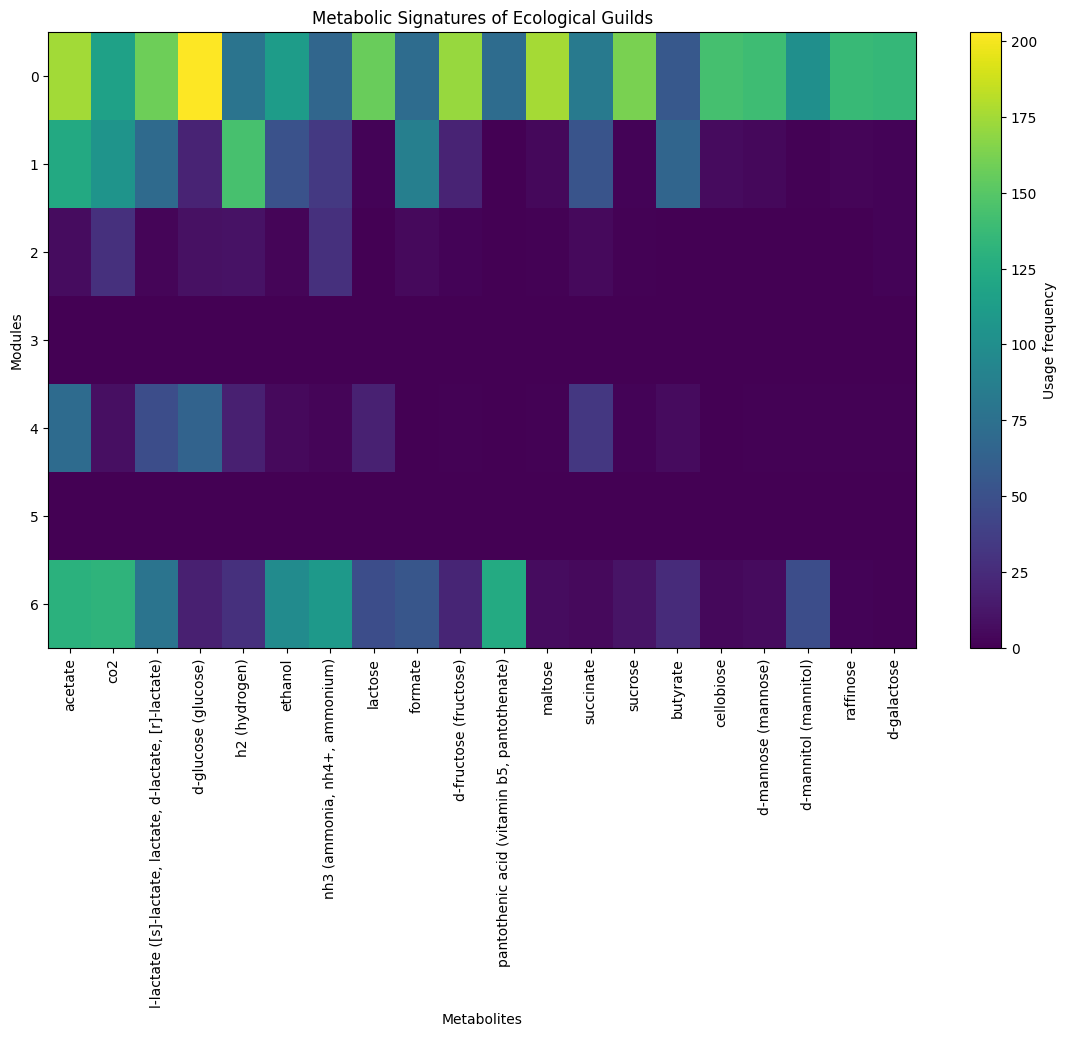

In [112]:
plt.figure(figsize=(14, 8))

plt.imshow(heatmap, aspect="auto")

plt.xticks(
    range(len(top_metabolites)),
    top_metabolites,
    rotation=90
)

plt.yticks(
    range(len(modules)),
    modules
)

plt.xlabel("Metabolites")
plt.ylabel("Modules")
plt.title("Metabolic Signatures of Ecological Guilds")

plt.colorbar(label="Usage frequency")

plt.show()

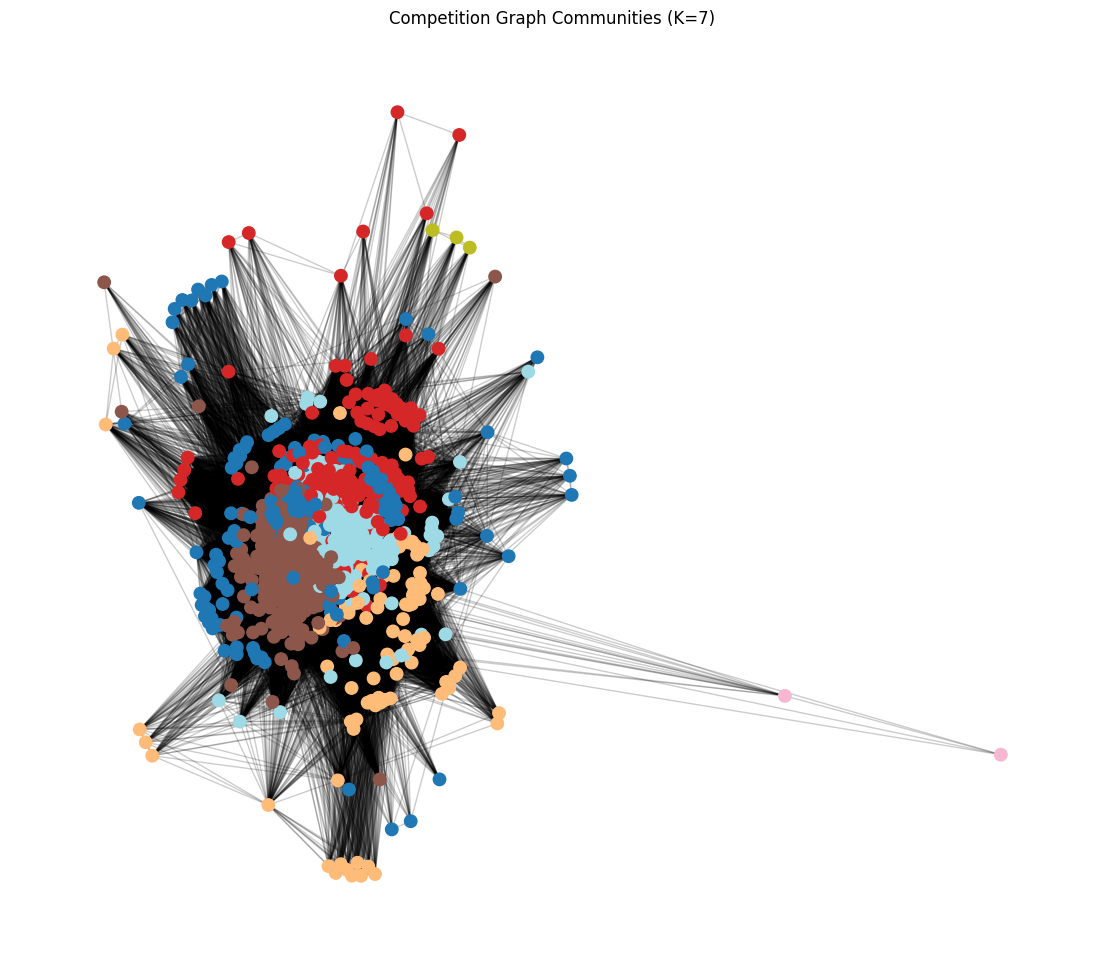

In [120]:
communities = nx.community.louvain_communities(G, seed=123, weight='weight')


node_community = {}
for cid, comm in enumerate(communities):
	for n in comm:
		node_community[n] = cid

node_colors = [node_community[n] for n in G.nodes()]

pos = nx.spring_layout(G, seed=42, weight="weight")

plt.figure(figsize=(14, 12))
nx.draw_networkx_nodes(
	G,
	pos,
	node_size=80,
	node_color=node_colors,
	cmap=plt.cm.tab20
)
nx.draw_networkx_edges(
	G,
	pos,
	alpha=0.2
)

plt.title(f"Competition Graph Communities (K={len(communities)})")
plt.axis("off")
plt.show()


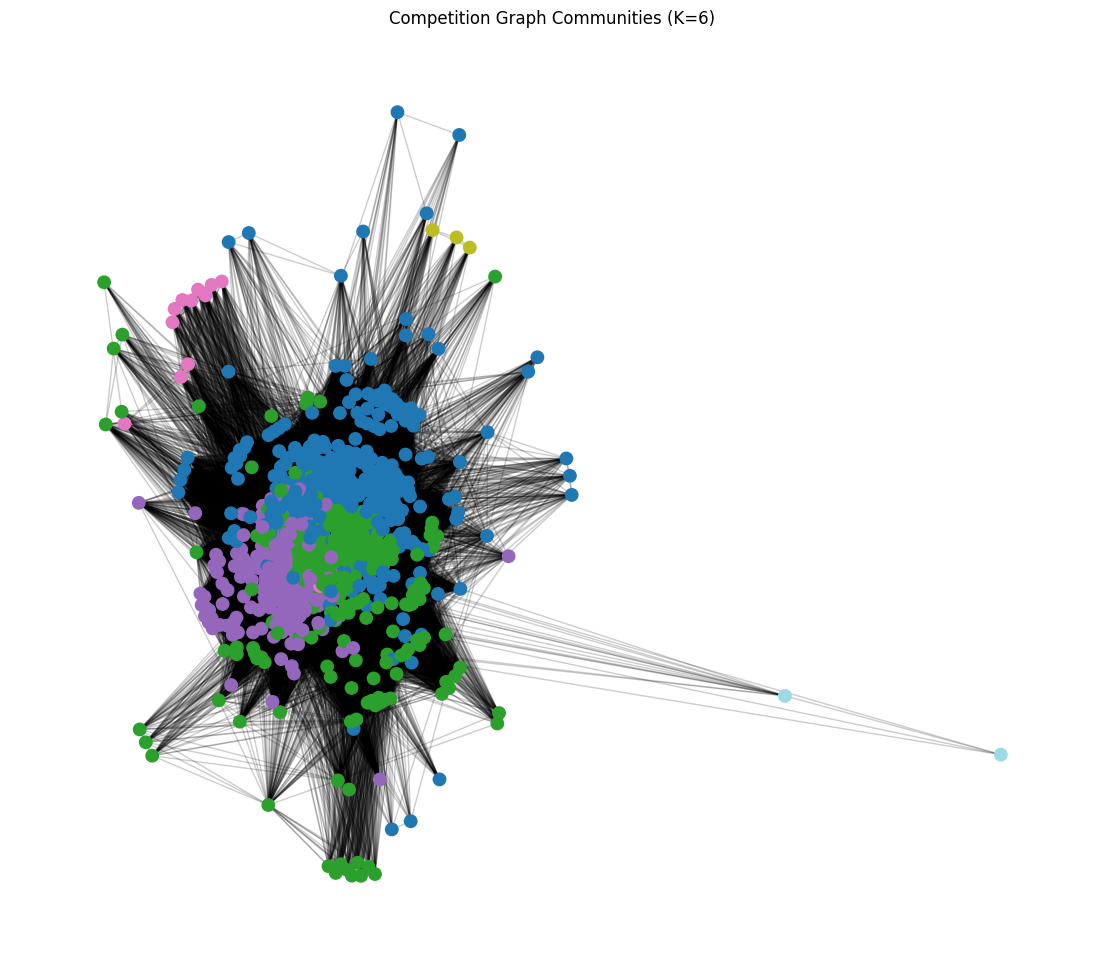

In [121]:
communities = nx.community.greedy_modularity_communities(G, weight="weight")

node_community = {}
for cid, comm in enumerate(communities):
	for n in comm:
		node_community[n] = cid

node_colors = [node_community[n] for n in G.nodes()]

pos = nx.spring_layout(G, seed=42, weight="weight")

plt.figure(figsize=(14, 12))
nx.draw_networkx_nodes(
	G,
	pos,
	node_size=80,
	node_color=node_colors,
	cmap=plt.cm.tab20
)
nx.draw_networkx_edges(
	G,
	pos,
	alpha=0.2
)

plt.title(f"Competition Graph Communities (K={len(communities)})")
plt.axis("off")
plt.show()

In [122]:
target_module = 0

module_species = module_to_species[target_module]

print("Species in module:")
print(module_species)

Species in module:
['absiella dolichum', 'acetobacterium woodii', 'acholeplasma laidlawii', 'achromobacter xylosoxidans', 'acidovorax avenae', 'acidovorax delafieldii', 'actinobacillus succinogenes', 'actinosynnema mirum', 'aerococcus viridans', 'aeromicrobium marinum', 'aeromonas hydrophila', 'aeromonas salmonicida', 'alistipes indistinctus', 'alloprevotella rava', 'aminobacterium colombiense', 'anaerobutyricum hallii', 'anaerococcus hydrogenalis', 'anaerococcus lactolyticus', 'anaerococcus obesiensis', 'anaerococcus prevotii', 'anaerococcus tetradius', 'anaerococcus vaginalis', 'anaerostipes hadrus', 'anaerotruncus colihominis', 'bacteroides caccae', 'bacteroides coprosuis', 'bacteroides dorei', 'bacteroides finegoldii', 'bacteroides fragilis', 'bacteroides intestinalis', 'bacteroides massiliensis', 'bacteroides nordii', 'bacteroides ovatus', 'bacteroides pyogenes', 'bacteroides thetaiotaomicron', 'bacteroides uniformis', 'bacteroides vulgatus', 'bacteroides xylanisolvens', 'bifidoba

In [123]:
species_index = {
    s: i for i, s in enumerate(module_species)
}

n = len(module_species)

A = np.zeros((n, n))

In [124]:
for s1, s2, d in G_jaccard.edges(data=True):

    if s1 not in species_index:
        continue

    if s2 not in species_index:
        continue

    i = species_index[s1]
    j = species_index[s2]

    weight = d["weight"]

    # competition is NEGATIVE
    A[i, j] = weight
    A[j, i] = weight

In [125]:
for i in range(n):

    A[i, i] = 1.0

In [126]:
r = np.random.uniform(
    0.5,
    1.5,
    size=n
)

In [127]:
N0 = np.random.uniform(
    0.1,
    1.0,
    size=n
)

In [128]:
from scipy.integrate import solve_ivp

In [129]:
def glv(t, N, r, A):

    dNdt = np.zeros_like(N)

    for i in range(len(N)):

        interaction = np.sum(
            A[i] * N
        )

        dNdt[i] = r[i] * N[i] * (
            1 - interaction
        )

    return dNdt

In [130]:
t_span = (0, 100)

t_eval = np.linspace(0, 100, 1000)

solution = solve_ivp(
    glv,
    t_span,
    N0,
    args=(r, A),
    t_eval=t_eval
)

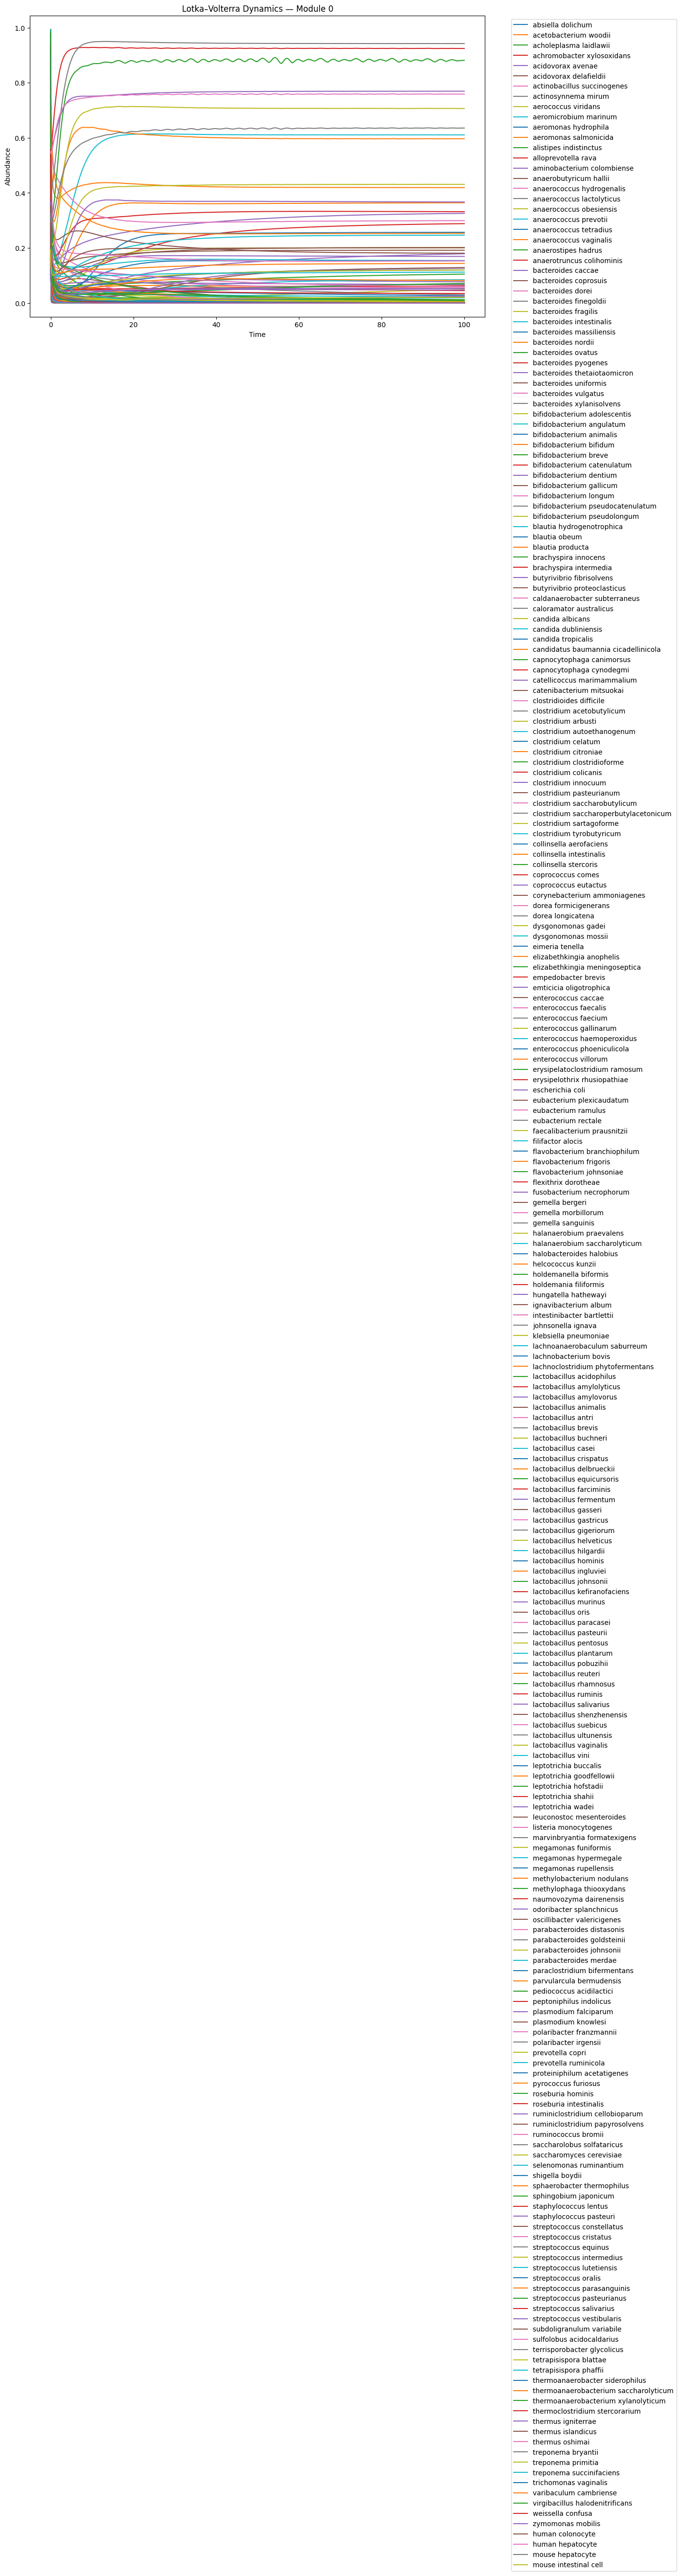

In [131]:
plt.figure(figsize=(12, 8))

for i, species in enumerate(module_species):

    plt.plot(
        solution.t,
        solution.y[i],
        label=species
    )

plt.xlabel("Time")
plt.ylabel("Abundance")
plt.title(
    f"Lotka–Volterra Dynamics — Module {target_module}"
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.show()